In [15]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [16]:
# 1. Setup Parameters (Identical to JAX)
N, K = 100, 2.0
dt, steps = 0.1, 2000

In [17]:
# 2. Initialization
# Using the same seed (42) to ensure the random "universe" is identical
rng = np.random.default_rng(42)

omega = rng.normal(loc=0.0, scale=1.0, size=N)
theta = rng.uniform(low=0.0, high=2 * np.pi, size=N)

In [18]:
# Define the derivative function (Kuramoto math)
def f(th): 
    # Broadcasting: (1, N) - (N, 1) = (N, N) matrix
    return omega + (K/N) * np.sin(th[None, :] - th[:, None]).sum(axis=1)


In [19]:
# Pre-allocate array for history (equivalent to what scan does internally)
r_history_np = np.zeros(steps)

In [20]:
# --- EXECUTION BLOCK ---
start = time.perf_counter()

# 3. The "For Loop" version of the simulation
for i in range(steps):
    # Calculate Order Parameter r (Current state)
    z = np.mean(np.exp(1j * theta))
    r_history_np[i] = np.abs(z)
    
    # Standard RK4 math
    k1 = f(theta)
    k2 = f(theta + dt/2 * k1)
    k3 = f(theta + dt/2 * k2)
    k4 = f(theta + dt * k3)
    
    # Update theta for the next iteration
    theta = theta + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)

end = time.perf_counter()
# -----------------------
print(f"NumPy Execution time: {end - start:.4f} seconds")

NumPy Execution time: 1.0935 seconds


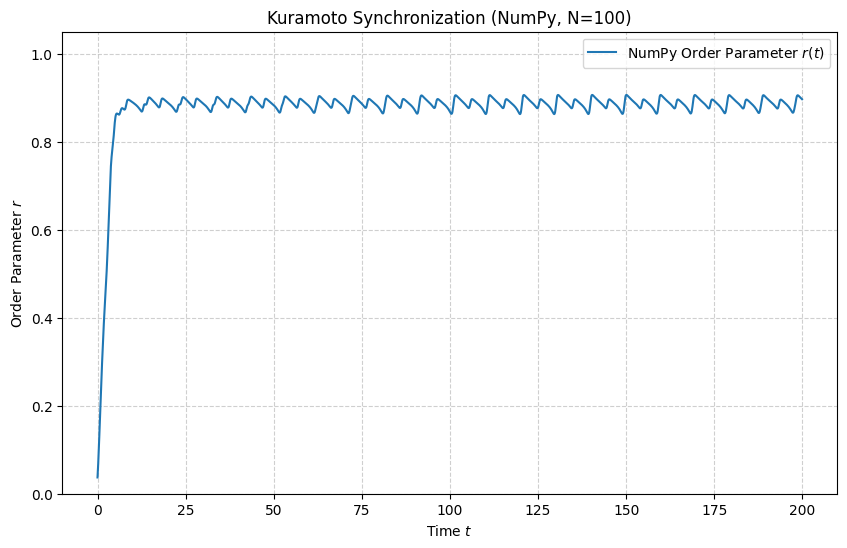

In [21]:
# Plotting
plt.figure(figsize=(10, 6))
plt.plot(np.arange(steps) * dt, r_history_np, label='NumPy Order Parameter $r(t)$')
plt.xlabel("Time $t$")
plt.ylabel("Order Parameter $r$")
plt.title(f"Kuramoto Synchronization (NumPy, N={N})")
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 1.05)
plt.legend()
plt.show()